In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  seaborn as sns

In [2]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


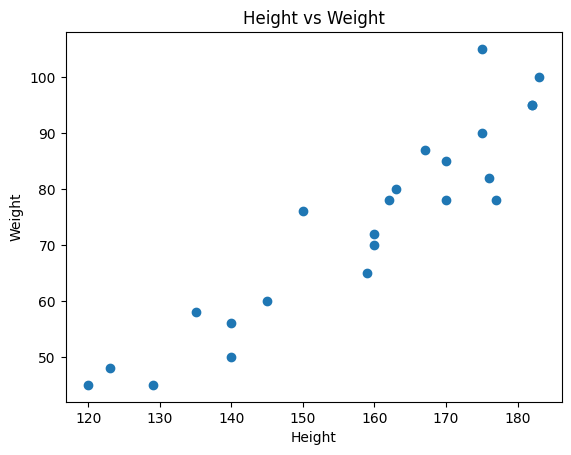

In [3]:
plt.scatter(df['Height'],df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
#devide my dataset into dependent and indepent features
X = df[['Weight']] #independent feature
y = df[['Height']]#dependent feature

In [6]:
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.20,random_state = 42)
#X_train is the independent feaure and y_train is the dependent feature

In [7]:
X.shape

(23, 1)

In [8]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18, 1), (5, 1))

In [9]:
# standardize the dataset Train independent data
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()


In [11]:
X_train =scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)


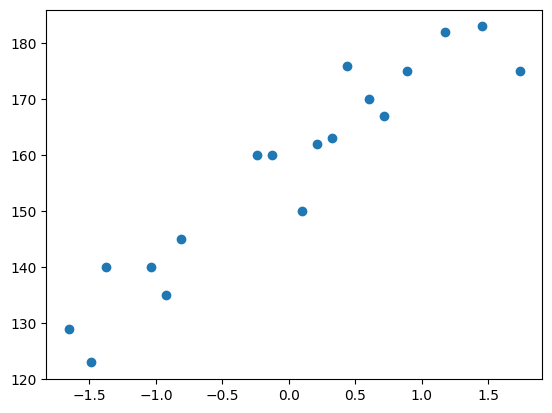

In [12]:
plt.scatter(X_train,y_train)

In [13]:
# Train the simple linear regression model
from sklearn.linear_model import LinearRegression

In [14]:
reg = LinearRegression()


In [15]:
reg.fit(X_train,y_train)

LinearRegression()

In [16]:
print("The slope or coefficient of weight is ",reg.coef_)
print("Intercept:",reg.intercept_)

The slope or coefficient of weight is  [[17.03440872]]
Intercept: [157.5]


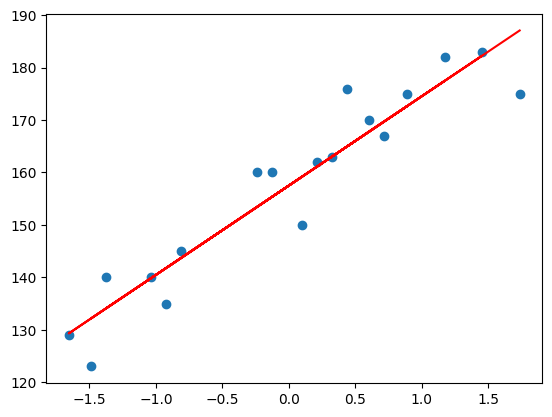

In [17]:
plt.scatter(X_train,y_train)
plt.plot(X_train,reg.predict(X_train),color='red')

### prediction of train data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_train =157.5 + 17.03(X_train)
          
### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =157.5 + 17.03(X_test)

In [18]:
y_pred_test = reg.predict(X_test)

In [19]:
y_pred_test,y_test

(array([[161.08467086],
        [161.08467086],
        [129.3041561 ],
        [177.45645118],
        [148.56507414]]),
     Height
 15     177
 9      170
 0      120
 8      182
 17     159)

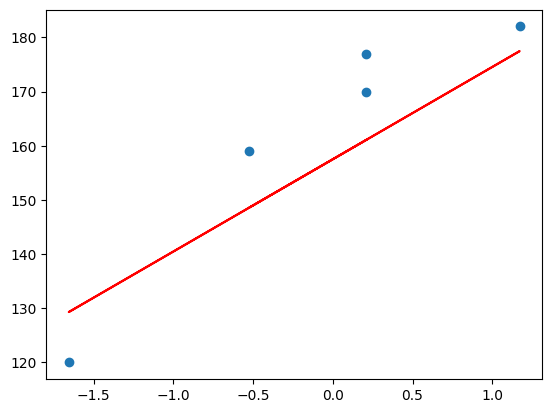

In [20]:
plt.scatter(X_test,y_test)
plt.plot(X_test,reg.predict(X_test),color='red')

In [21]:
# Performance Metrics
# MSE,MAE, RMSE,R2 score
# adjusted_r2 
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [22]:
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print("Mean Squared Error:",mse)
print("Mean Absolute Error:",mae)
print("Root Mean Squared Error:",rmse)

Mean Squared Error: 109.77592599051664
Mean Absolute Error: 9.822657814519232
Root Mean Squared Error: 10.477400726827081


In [23]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)

**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [24]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

Remember that r2 > adjusted r2

# Assumtion

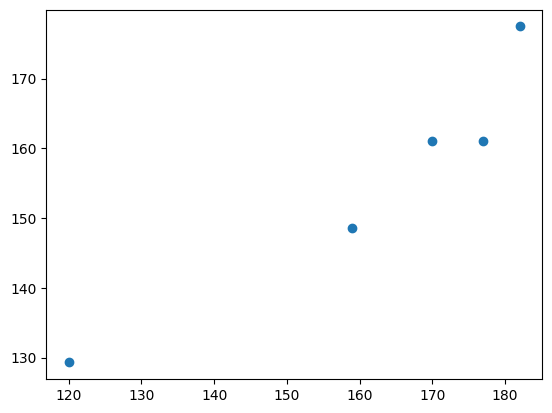

In [26]:
plt.scatter(y_test,y_pred_test)
#If the plots are linear then the model is good

In [27]:
#Residuals
residuals = y_test - y_pred_test
residuals 

,Height
15,15.915329
9,8.915329
0,-9.304156
8,4.543549
17,10.434926


C:\Users\ruchi\AppData\Local\Temp\ipykernel_2816\2779034658.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: ylabel='Density'>

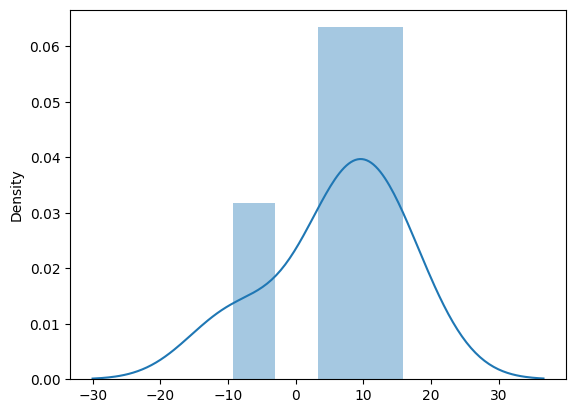

In [29]:
import seaborn as sns
sns.distplot(residuals,kde=True)
#If the distribution is normal then the model is good

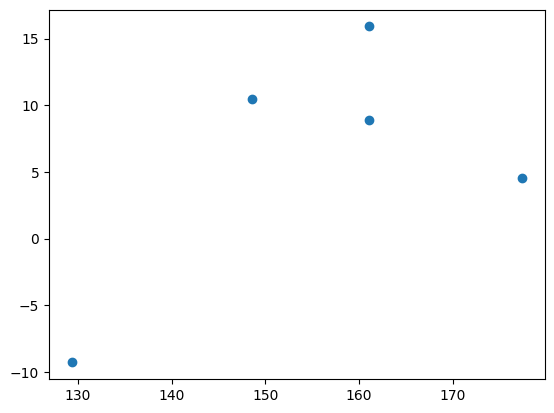

In [30]:
#Scatter plot with resplect toprediction and residuals
#uniform distribution
plt.scatter(y_pred_test,residuals)